# The Dot Product, Length, and Angle

**This notebook teaches the dot product from scratch, it assumes only that a vector is a column of numbers drawn as an arrow.**

How aligned are two vectors? How long is one? What angle is between them? All three questions are answered by a single operation, the **dot product**. It multiplies two vectors into one number, and from it we get length, distance, angle, and the test for perpendicularity. It is the workhorse behind measuring similarity between data points.

## Learning objectives

- Compute the **dot product** $\mathbf{v}\cdot\mathbf{w}$ and read its meaning.
- Write it as a **row times a column**, $\mathbf{v}^{\top}\mathbf{w}$.
- Get a vector's **length** and the **distance** between two vectors from the dot product.
- Find the **angle** between vectors and test for **orthogonality** (perpendicularity).

## Background

Vectors are written as **columns** (the convention throughout this course):

$$\mathbf{v} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix}, \qquad \mathbf{w} = \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}.$$

The **dot product** multiplies matching components and adds:

$$\mathbf{v}\cdot\mathbf{w} = \sum_{i} v_i w_i = v_1 w_1 + v_2 w_2 + \cdots.$$

**This is the one place a row vector belongs.** Tipping $\mathbf{v}$ on its side, writing its column as a row, which we denote $\mathbf{v}^{\top}$ and call the **transpose**, lets us read the dot product as a *row sliding across a column*, pairing off entries as it goes:

$$\mathbf{v}^{\top}\mathbf{w} = \begin{bmatrix} 1 & 2 & 1 \end{bmatrix} \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix} = (1)(2) + (2)(-1) + (1)(3) = 3.$$

So $\mathbf{v}\cdot\mathbf{w}$ and $\mathbf{v}^{\top}\mathbf{w}$ are two names for the same number. The row form is worth getting used to: it is exactly the pattern behind matrix multiplication later on (each entry of a product is a row dotted with a column). Outside of this row-times-column setting, we keep writing vectors as columns.

A vector's **length** is the square root of its dot product with itself, $\|\mathbf{v}\| = \sqrt{\mathbf{v}\cdot\mathbf{v}}$, and the **distance** between two vectors is $\|\mathbf{v} - \mathbf{w}\|$. The dot product also encodes the **angle** $\theta$ between the vectors:

$$\cos\theta = \frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\,\|\mathbf{w}\|}.$$

When $\mathbf{v}\cdot\mathbf{w} = 0$ the vectors are **orthogonal** (at a right angle).

## This notebook covers

1. Computing the dot product (and the row-times-column view).
2. Length from the dot product (and other norms).
3. Distance between vectors.
4. Angle and orthogonality.

**Prerequisites:** `U2-2_Vectors-1_ArrowsAndOps`

**Dataset:** none, vectors are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Arc

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# plotting helper: draw one vector as an arrow starting at `tail`
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles="xy", scale_units="xy",
              scale=1, color=color, label=label, alpha=alpha, width=0.008)

# plotting helper: mark the angle between two vectors with an arc at the origin
def draw_angle(ax, v, w, radius=1.0, color="white", label=None):
    a1 = math.degrees(math.atan2(v[1], v[0])) % 360
    a2 = math.degrees(math.atan2(w[1], w[0])) % 360
    start, end = sorted([a1, a2])
    if end - start > 180:                 # always sweep the smaller of the two angles
        start, end = end, start + 360
    ax.add_patch(Arc((0, 0), 2*radius, 2*radius, theta1=start, theta2=end,
                     color=color, lw=1.5))
    if label:
        mid = math.radians((start + end) / 2)
        ax.text(1.3*radius*math.cos(mid), 1.3*radius*math.sin(mid), label,
                color=color, ha="center", va="center")

## 1. Computing the dot product

Multiply matching components and add them up. For

$$\mathbf{v} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix}, \qquad \mathbf{w} = \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}$$

the dot product is $1\cdot2 + 2\cdot(-1) + 1\cdot3 = 2 - 2 + 3 = 3$, or, laid out as a row against a column,

$$\mathbf{v}^{\top}\mathbf{w} = \begin{bmatrix} 1 & 2 & 1 \end{bmatrix}\begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix} = 3.$$

We do it with an explicit loop and then with `np.dot`.

In [2]:
v = np.array([1, 2, 1])
w = np.array([2, -1, 3])

helpers.show(v, name="v")     # columns, as always
helpers.show(w, name="w")

# the transpose lays v out as a row -- the only place we write a vector horizontally
helpers.show(v.reshape(1, -1), name=r"v^\top")

# by hand: multiply matching parts, add them up
total = 0
for i in range(len(v)):
    total = total + v[i] * w[i]

print("dot product by hand =", total)
print("np.dot(v, w)        =", np.dot(v, w))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

dot product by hand = 3
np.dot(v, w)        = 3


## 2. Length from the dot product

A vector dotted with **itself** gives the sum of its squares, so its length is $\|\mathbf{v}\| = \sqrt{\mathbf{v}\cdot\mathbf{v}}$. For $\mathbf{v} = \begin{bmatrix}3\\4\end{bmatrix}$ that is $\sqrt{9 + 16} = 5$.

(This "length" is the **L2 norm**. Two other useful measures of size are the **L1 norm**, add the absolute values, and the **L∞ norm**, the largest absolute value. For this $\mathbf{v}$ they are $7$ and $4$.)

In [3]:
v = np.array([3, 4])
helpers.show(v, name="v")

length = math.sqrt(np.dot(v, v))     # sqrt of v dotted with itself
print("length (L2 norm) =", length)

print("L1 norm  =", np.linalg.norm(v, 1))       # |3| + |4| = 7
print("L2 norm  =", np.linalg.norm(v, 2))       # 5
print("Linf norm=", np.linalg.norm(v, np.inf))  # max(|3|,|4|) = 4

<IPython.core.display.Math object>

length (L2 norm) = 5.0
L1 norm  = 7.0
L2 norm  = 5.0
Linf norm= 4.0


## 3. Distance between two vectors

The **distance** between two vectors (or data points) is the length of their difference, $\|\mathbf{v} - \mathbf{w}\|$. The plot shows why: the difference $\mathbf{v} - \mathbf{w}$ is the arrow joining the two heads, so *its* length is the gap between the two points.

<IPython.core.display.Math object>

distance between v and w = 5.0


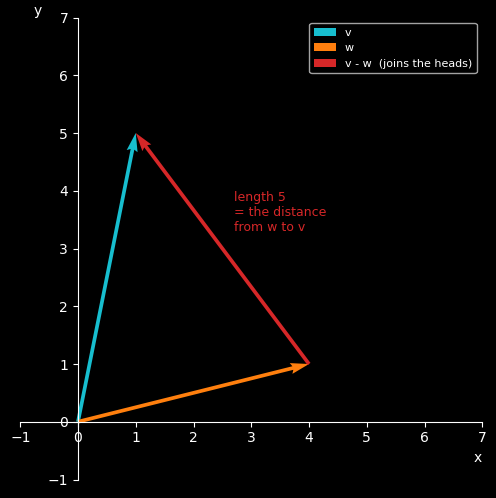

In [4]:
v = np.array([1, 5])
w = np.array([4, 1])

difference = v - w
helpers.show(difference, name="v - w")

distance = math.sqrt(np.dot(difference, difference))
print("distance between v and w =", distance)   # sqrt(9 + 16) = 5

# --- graphics: the difference is the arrow between the two heads ---
fig, ax = plt.subplots(figsize=(6, 6))
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, (0, 0), w, "tab:orange", "w")
arrow(ax, w, v - w, "tab:red", "v - w  (joins the heads)")

ax.text(2.7, 3.3, "length 5\n= the distance\nfrom w to v", color="tab:red", fontsize=9)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 7); ax.set_ylim(-1, 7); ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## 4. Angle and orthogonality

Rearranging $\cos\theta = \dfrac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\,\|\mathbf{w}\|}$ gives the angle between two vectors. If the dot product is **zero**, the angle is $90^\circ$, the vectors are **orthogonal**.

The first two panels below draw that angle as an arc. On the left, $\mathbf{v}$ and $\mathbf{w}$ are picked **at random**, so the opening is whatever it happens to be, the arc is labelled with the angle actually computed, and the title with the dot product actually computed. On the right, a deliberately chosen perpendicular pair, marked with the usual small square.

The third panel sweeps one vector all the way around and plots the dot product as it goes, which shows what the sign is telling you:

- **positive** when the vectors lean the same way (angle under $90^\circ$),
- **zero** exactly at $90^\circ$: orthogonal,
- **negative** when they lean apart (angle over $90^\circ$).

That sign is the whole intuition behind "how aligned are these two?"

v . w = 1.08
angle between v and w: 50.6 degrees
a . b = 0 -> orthogonal (90 degrees)


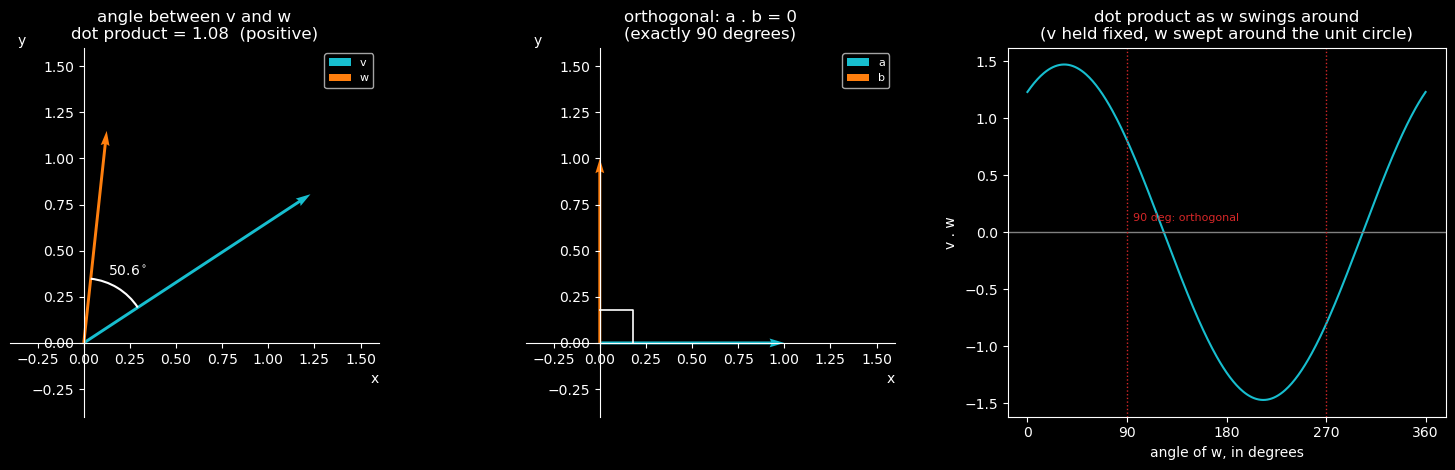

In [5]:
# Two vectors picked at random, so the angle is whatever it happens to be.
# The seed only fixes WHICH random pair we get, so the figure below matches on a re-run;
# every label is computed from v and w, never typed in, so it stays true if you change it.
np.random.seed(46)
v = np.random.rand(2)**2 * 2
w = np.random.rand(2)**2 * 2

dot_vw = np.dot(v, w)
cos_theta = dot_vw / (np.linalg.norm(v) * np.linalg.norm(w))
angle_degrees = math.degrees(math.acos(cos_theta))
print(f"v . w = {dot_vw:.2f}")
print(f"angle between v and w: {angle_degrees:.1f} degrees")

# orthogonal example: dot product is zero
a = np.array([1, 0])
b = np.array([0, 1])
print("a . b =", np.dot(a, b), "-> orthogonal (90 degrees)" if np.dot(a, b) == 0 else "")

# --- graphics: the angle as an arc, and the dot product as the angle sweeps ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# panel 1: whatever angle the random pair happens to make
ax = axes[0]
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, (0, 0), w, "tab:orange", "w")
draw_angle(ax, v, w, radius=0.35, label=rf"${angle_degrees:.1f}^\circ$")
ax.set_title(f"angle between v and w\ndot product = {dot_vw:.2f}  "
             f"({'positive' if dot_vw > 0 else 'negative'})")

# panel 2: orthogonal -- dot product 0, marked with a right-angle square
ax = axes[1]
arrow(ax, (0, 0), a, "tab:cyan", "a")
arrow(ax, (0, 0), b, "tab:orange", "b")
ax.plot([0, 0.18, 0.18], [0.18, 0.18, 0], color="white", lw=1.2)   # right-angle marker
ax.set_title("orthogonal: a . b = 0\n(exactly 90 degrees)")

for ax in axes[:2]:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_xlim(-0.4, 1.6); ax.set_ylim(-0.4, 1.6); ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

# panel 3: hold v fixed, swing w around, and watch the dot product
ax = axes[2]
angles = np.linspace(0, 360, 361)
dots = [np.dot(v, [math.cos(math.radians(t)), math.sin(math.radians(t))]) for t in angles]
ax.plot(angles, dots, color="tab:cyan")
ax.axhline(0, color="gray", lw=1)
for t in (90, 270):
    ax.axvline(t, color="tab:red", ls=":", lw=1)
ax.text(95, 0.1, "90 deg: orthogonal", color="tab:red", fontsize=8)
ax.set_xlabel("angle of w, in degrees")
ax.set_ylabel("v . w")
ax.set_title("dot product as w swings around\n(v held fixed, w swept around the unit circle)")
ax.set_xticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()

## 5. Summary

- The **dot product** $\mathbf{v}\cdot\mathbf{w} = \sum v_i w_i$ turns two vectors into one number.
- Written as a **row times a column** it is $\mathbf{v}^{\top}\mathbf{w}$, the same number, and the only setting in which we write a vector horizontally.
- **Length** $\|\mathbf{v}\| = \sqrt{\mathbf{v}\cdot\mathbf{v}}$; **distance** $= \|\mathbf{v} - \mathbf{w}\|$.
- **Angle:** $\cos\theta = \dfrac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\|\mathbf{w}\|}$; a dot product of **0** means **orthogonal**.

Next: using these to **project** one vector onto another and to measure **similarity** (`U2-2_Vectors-3_ProjectionAndSimilarity`).